#**Student Data Visualizer**

This project is a command-line based student data analysis system built using NumPy and Matplotlib. It allows users to dynamically input student marks, perform statistical analysis, and visualize performance through graphs.

**Objective:**\
The goal of this project is to:
- Understand numerical data handling using NumPy
- Perform basic data analysis (averages, ranking)
- Visualize data using Matplotlib
- Build a simple interactive system with persistent storage (JSON)

**Features:**
- Add student marks dynamically
- Display stored student data
- Compute:
  - Student-wise averages
  - Rankings based on total marks
- Visualize data using:
  - Bar Graph (total marks per student)
  - Line Graph (performance trend)
- Clear stored data
- Save and load data using JSON

**Technologies Used:**
- Python
- Numpy
- Matplotlib
- JSON

**Workflow:**
- User inputs the number of subjects
- Data is loaded from JSON(if available)
- User performs operations via CLI:
  - Add student
  - Analyse data
  - Visualize graphs
- Data is saved automatically

#**Importing Libraries**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import json

#**Data Loading:**
The save data and load data methods below are used to save student's data taken through CLI and store them in a JSON file. This data is later accessed through the load data function internally and the modifications are automatically saved.

In [ ]:
n = int(input("Enter the number of subjects: "))

def load_data():
    global marks
    try:
        with open("marks.json", "r") as f:
            data = json.load(f)
            if data:
                    temp_marks = np.array(data)
                    if temp_marks.shape[1] == n:
                        return temp_marks
                    else:
                        print(f"Invalid input")
    except:
        pass
    return np.empty((0, n))

marks = load_data()

def save_data():
    with open("marks.json", "w") as f:
        json.dump(marks.tolist(), f)

#**Functions:**
The operations you perform through the command line interface are given below.

Enter the number of subjects: 3

***** Available Operations *****
1. Show Data
2. Add student
3. Clear Data
4. Bar graph
5. line graph
6. Histofram
7. Exit
*********************************
Enter your choice: 1

----- Student Data -----
No students found.
------------------------

***** Available Operations *****
1. Show Data
2. Add student
3. Clear Data
4. Bar graph
5. line graph
6. Histofram
7. Exit
*********************************
Enter your choice: 2
Enter 3 marks (space separated): 89 90 92
Student Added !!

***** Available Operations *****
1. Show Data
2. Add student
3. Clear Data
4. Bar graph
5. line graph
6. Histofram
7. Exit
*********************************
Enter your choice: 2
Enter 3 marks (space separated): 90 92 91
Student Added !!

***** Available Operations *****
1. Show Data
2. Add student
3. Clear Data
4. Bar graph
5. line graph
6. Histofram
7. Exit
*********************************
Enter your choice: 2
Enter 3 marks (space separated): 78 80 82
Student Added !!

****

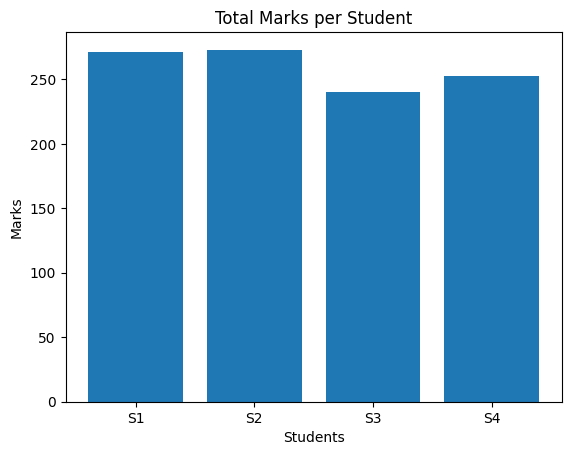


***** Available Operations *****
1. Show Data
2. Add student
3. Clear Data
4. Bar graph
5. line graph
6. Histofram
7. Exit
*********************************
Enter your choice: 5


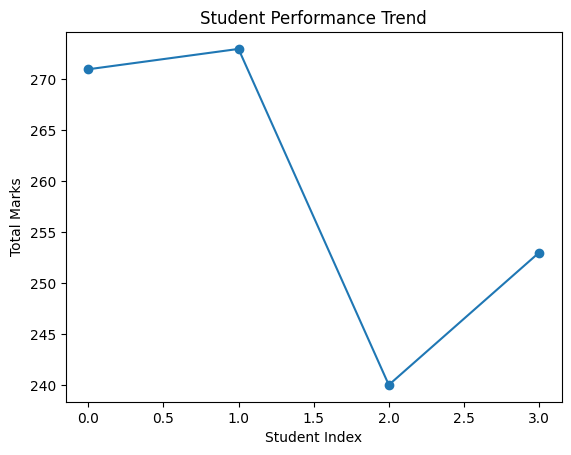


***** Available Operations *****
1. Show Data
2. Add student
3. Clear Data
4. Bar graph
5. line graph
6. Histofram
7. Exit
*********************************
Enter your choice: 6


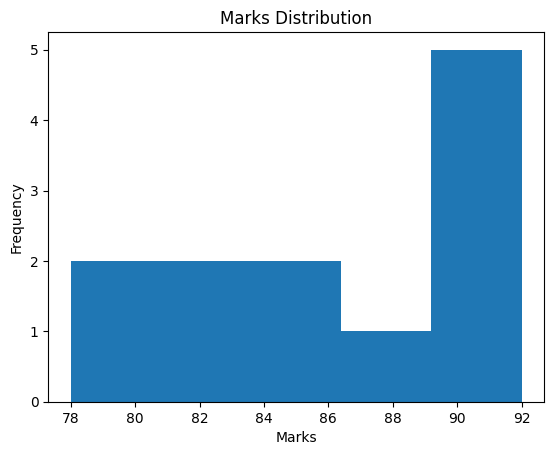


***** Available Operations *****
1. Show Data
2. Add student
3. Clear Data
4. Bar graph
5. line graph
6. Histofram
7. Exit
*********************************
Enter your choice: 3
Data Cleared.

***** Available Operations *****
1. Show Data
2. Add student
3. Clear Data
4. Bar graph
5. line graph
6. Histofram
7. Exit
*********************************
Enter your choice: 1

----- Student Data -----
No students found.
------------------------

***** Available Operations *****
1. Show Data
2. Add student
3. Clear Data
4. Bar graph
5. line graph
6. Histofram
7. Exit
*********************************
Enter your choice: 7
Exiting....


In [ ]:
def show_data():
    print("\n----- Student Data -----")
    if marks.size == 0:
        print("No students found.")
    else:
        for i, x in enumerate(marks):
            print(f"Student {i+1}: {x}")
    print("------------------------")

def add_std():
    global marks
    try:
        user_input = input(f"Enter {n} marks (space separated): ")
        new_marks = list(map(int, user_input.split()))
        if len(new_marks) != n:
            print(f"Error: You must enter exactly {n} marks.")
            return
        if marks.size == 0:
            marks = np.array([new_marks])
        else:
            marks = np.vstack((marks, new_marks))
        save_data()
        print("Student Added !!")
    except:
        print("Invalid Input. Please enter numbers only.")

def clear_data():
    global marks
    marks = np.empty((0, n))
    save_data()
    print("Data Cleared.")


def bar_graph():
    total = np.sum(marks,axis = 1)
    students = [f"S{i+1}" for i in range(len(total))]
    plt.figure()
    plt.bar(students, total)
    plt.title("Total Marks per Student")
    plt.xlabel("Students")
    plt.ylabel("Marks")
    plt.show(block=False)
    plt.pause(0.1)

def line_graph():
    total = np.sum(marks, axis=1)
    plt.figure()
    plt.plot(total, marker='o')
    plt.title("Student Performance Trend")
    plt.xlabel("Student Index")
    plt.ylabel("Total Marks")
    plt.show(block=False)
    plt.pause(0.1)

def histogram():
    if marks.shape[0] == 0:
        print("No data to display.")
        return

    flat = marks.flatten()
    plt.figure()
    plt.hist(flat, bins=5)
    plt.title("Marks Distribution")
    plt.xlabel("Marks")
    plt.ylabel("Frequency")
    plt.show()

while True:
    print("\n***** Available Operations *****")
    print("1. Show Data\n2. Add student\n3. Clear Data\n4. Bar graph\n5. line graph\n6. Histofram\n7. Exit")
    print("*********************************")
    try:
        choice = int(input("Enter your choice: "))
        if choice == 1: show_data()
        elif choice == 2: add_std()
        elif choice == 3: clear_data()
        elif choice == 4: bar_graph()
        elif choice == 5: line_graph()
        elif choice == 6: histogram()
        elif choice == 7:
            print("Exiting....")
            break
    except:
        print("Invalid Choice.")